#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 5: Estimación de la demanda de bicicletas compartidas utilizando *Neural Networks*.  </center>

## Sub objetivos:

Parte 1: Repensar el pipeline de preprocesamiento basico utilizado en el Taller 3
Parte 2: Entrenar un modelo utilizando la arquitectura del ejemplo del Capıtulo 10 del
libro.
– Ver seccion Building a Regression MLP Using the Sequential API o repositorio del libro
– ¿Cuantos parametros tiene la red?
– ¿Cual es el desempeno? ¿C´omo lo mejorarıa?
Parte 3: Optimizar la arquitectura para este problema en particular usando las herramientas de busqueda de hiperpar´ametros de KerasTuner.
– Ver ejemplos en seccion Fine-Tuning Neural Networks Hyperparameters.
– Probar el tip que se sugiere en la seccion Number of Neurons per Hidden Layer.
- Comparar con arboles


# Introducción

En esta actividad se retomará el problema de la competencia [*Bike Sharing Demand*](https://www.kaggle.com/c/bike-sharing-demand) visto en el Taller 3.
Esta vez las estimaciónes deben obtenerse utilizando la herramienta: *Multilayer Perceptron* (MLP). Es importante mantener la función *Root Mean Squared Logarithmic Error* (RMSLE) como medida de desempeño de manera de poder comparar los resultados con los obtenidos en el Taller 3.

Tanto las preguntas teóricas como la parte práctica de esta actividad están ligadas al contenido del capítulo 10 (*Introduction to
Artificial Neural Networks with
Keras*) del libro del curso.


## Objetivos


*   Trabajar con modelos MLP utilizando la librería [*Keras*](https://keras.io/api/).
*   Probar algunas de las herramientas disponibles para la busqueda de hiperparámetros.

## Formas de trabajo

#### Opción 1: Trabajar localmente

##### Descarga de datos disponibles en Kaggle

La siguiente celda configura Kaggle usando la ruta relativa `keys/kaggle.json` y crea la carpeta `data/data_taller3` para guardar los datos del taller.

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
kaggle_dir = project_root / "keys"
kaggle_file = kaggle_dir / "kaggle.json"
data_dir = project_root / "data" / "data_taller3"
data_dir.mkdir(parents=True, exist_ok=True)

if not kaggle_file.exists():
    raise FileNotFoundError(
        f"No se encontro {kaggle_file.resolve()}. Descargue kaggle.json desde Kaggle y guardelo en keys/kaggle.json"
    )

if os.name != "nt":
    kaggle_file.chmod(0o600)

os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir.resolve())
print(f"KAGGLE_CONFIG_DIR = {os.environ['KAGGLE_CONFIG_DIR']}")
print(f"Usando credenciales de {kaggle_file.resolve()}")
print(f"Los datos se guardaran en {data_dir.resolve()}")

KAGGLE_CONFIG_DIR = /home/santig14/fing/taa/talleres/keys
Usando credenciales de /home/santig14/fing/taa/talleres/keys/kaggle.json
Los datos se guardaran en /home/santig14/fing/taa/talleres/data/data_taller3


Luego, descargue y descomprima el dataset de Demanda de Bicicletas dentro de `data/data_taller3`:

In [2]:
!mkdir -p data/data_taller3 && kaggle competitions download -c bike-sharing-demand -p data/data_taller3

import shutil
shutil.unpack_archive("data/data_taller3/bike-sharing-demand.zip", "data/data_taller3")

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
bike-sharing-demand.zip: Skipping, found more recently modified local copy (use --force to force download)


#### Opción 2:  Trabajar en *Colab*.

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2025/blob/main/talleres/taller5_demanda_de_bicicletas_con_NNs.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.

La siguiente celda monta el disco personal del drive:

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

A continuación, vaya a su cuenta de [Kaggle](https://www.kaggle.com/) (o cree una si aún no lo ha hecho), haga clic en el icono de perfil en la esquina superior derecha de la pantalla y seleccione "Your Account" en la lista desplegable. Luego, seleccione la viñeta "Account" y haga clic en "Create new API token". Entonces un archivo llamado kaggle.json se descargará automáticamente a su carpeta de descargas. Este archivo contiene sus credenciales de inicio de sesión para permitirle acceder a la API.

La siguiente celda realiza la configuración necesaria para obtener datos desde la plataforma Kaggle. Le solicitará que suba el archivo kaggle.json descargado anteriormente.

In [4]:
# import warnings
# warnings.filterwarnings('ignore')
# from google.colab import files
#
# El siguiente archivo solicitado es para habilitar la API de Kaggle en el entorno que está trabajando.
# Este archivo se descarga entrando a su perfíl de Kaggle, en la sección API, presionando donde dice: Create New API Token
#
# uploaded = files.upload()
#
# for fn in uploaded.keys():
#     print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))
#
# Then move kaggle.json into the folder where the API expects to find it.
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Una vez guardado el *token* se pueden descargar los datos, en este caso se bajarán los datos del dataset de Demanda de Bicicletas:

In [5]:
# !kaggle competitions download -c bike-sharing-demand

In [6]:
# !unzip bike-sharing-demand.zip

## Paquetes a utilizar

En esta actividad se utilizarán algunas bibliotecas auxiliares que deberán ser instaladas. Ejecutar la siguiente celda hasta que se ejecute sin errores. En caso de error, se puede instalar el paquete faltante desde el notebook con el comando:

`!pip install paquete_faltante`

In [7]:
#!pip install comet_ml
#!pip install keras_tuner
#!pip install tensorflow keras-tuner comet_ml
#!pip install seaborn

In [8]:
#import comet_ml in the top of your file
from comet_ml import Experiment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import keras_tuner as kt
import seaborn as sns
sns.set_theme(style="whitegrid")

df_train = pd.read_csv('data/data_taller3/train.csv')
df_test = pd.read_csv('data/data_taller3/test.csv')
df_submission = pd.read_csv('data/data_taller3/sampleSubmission.csv')

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
I0000 00:00:1776913826.543594  141410 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776913827.604364  141410 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776913833.379583  141410 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Parte 1 - Procesamiento de los datos

Dado que ya se ha familiarizado con los datos, se implementa el mismo preprocesamiento que utilizó en el Taller 3:


*   Se obtiene la hora, día de la semana, mes y año a partir de la fecha.
*   La cantidad se saca de los datos y se pone como etiqueta (y_train).
*   Se eliminan las columnas "datetime", "casual", "registered" y "count".


In [9]:
df_train['datetime'] = pd.to_datetime(df_train['datetime'])

df_train['hour'] = df_train['datetime'].dt.hour
df_train['weekday'] = df_train['datetime'].dt.weekday
df_train['month'] = df_train['datetime'].dt.month
df_train['year'] = df_train['datetime'].dt.year

y_train_full = df_train['count']
df_train = df_train.drop(['datetime', 'casual', 'registered', 'count'], axis=1) # hay que eliminarlas ya que tiene relación directa con la columna objetivo y no aparecen en el conjunto de *test*.

- Dado que se trabajará con redes neuronales, ¿Cree conveniente realizar alguna modificación en el preprocesamiento?. De ser así, impleméntelo.

In [10]:
print(f"Shape de X: {df_train.shape}")
print(f"Shape de y: {y_train_full.shape}")

display(df_train.head(20))

resumen = pd.DataFrame({
    "dtype": df_train.dtypes.astype(str),
    "nulos": df_train.isna().sum(),
    "unicos": df_train.nunique()
}).sort_index()

display(resumen)
display(y_train_full.describe().to_frame(name="y_train_full"))

Shape de X: (10886, 12)
Shape de y: (10886,)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,hour,weekday,month,year
0,1,0,0,1,9.84,14.395,81,0.0000,0,5,1,2011
1,1,0,0,1,9.02,13.635,80,0.0000,1,5,1,2011
2,1,0,0,1,9.02,13.635,80,0.0000,2,5,1,2011
3,1,0,0,1,9.84,14.395,75,0.0000,3,5,1,2011
4,1,0,0,1,9.84,14.395,75,0.0000,4,5,1,2011
5,1,0,0,2,9.84,12.880,75,6.0032,5,5,1,2011
6,1,0,0,1,9.02,13.635,80,0.0000,6,5,1,2011
7,1,0,0,1,8.20,12.880,86,0.0000,7,5,1,2011
8,1,0,0,1,9.84,14.395,75,0.0000,8,5,1,2011
9,1,0,0,1,13.12,17.425,76,0.0000,9,5,1,2011


,dtype,nulos,unicos
atemp,float64,0,60
holiday,int64,0,2
hour,int32,0,24
humidity,int64,0,89
month,int32,0,12
season,int64,0,4
temp,float64,0,49
weather,int64,0,4
weekday,int32,0,7
windspeed,float64,0,28


,y_train_full
count,10886.000000
mean,191.574132
std,181.144454
min,1.000000
25%,42.000000
50%,145.000000
75%,284.000000
max,977.000000


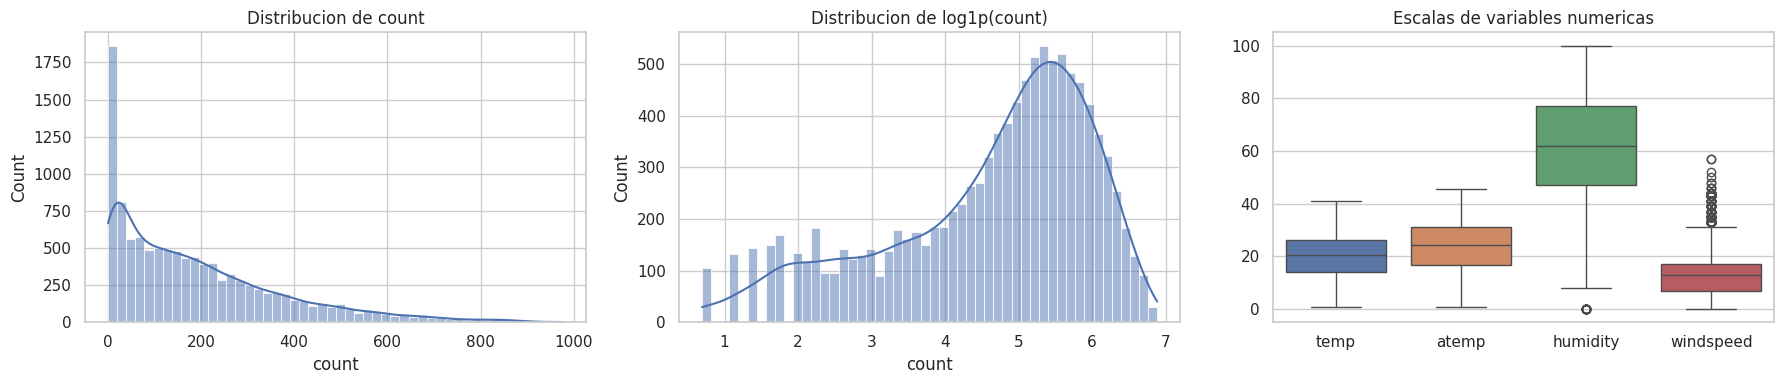

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(y_train_full, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de count")

sns.histplot(np.log1p(y_train_full), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribucion de log1p(count)")

sns.boxplot(data=df_train[["temp", "atemp", "humidity", "windspeed"]], ax=axes[2])
axes[2].set_title("Escalas de variables numericas")

plt.tight_layout()
plt.show()

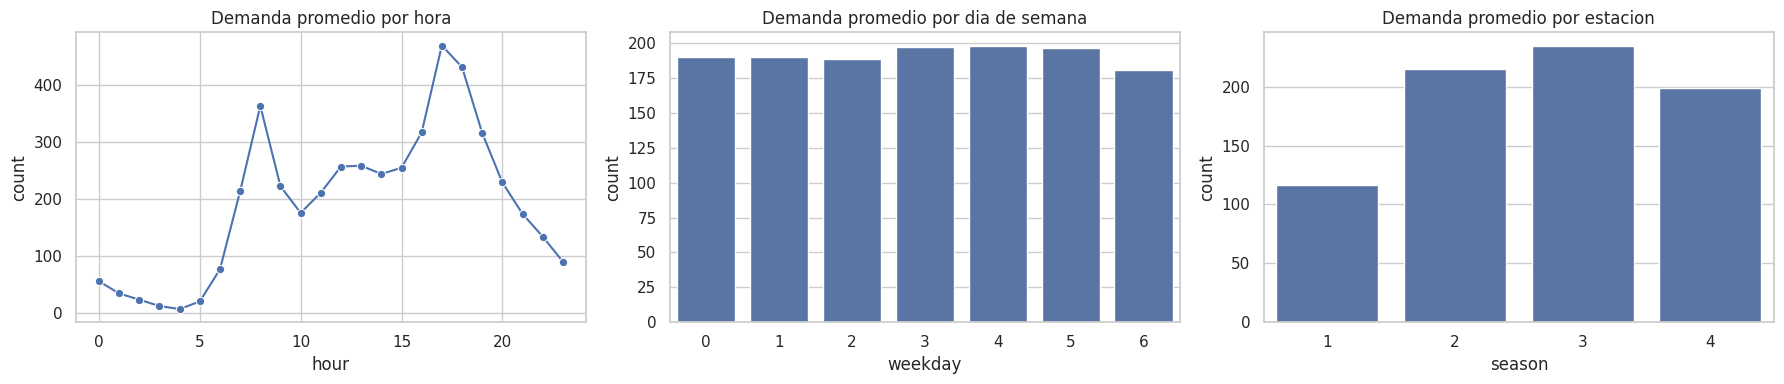

In [12]:
eda_df = df_train.copy()
eda_df["count"] = y_train_full.values

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

demanda_por_hora = eda_df.groupby("hour", as_index=False)["count"].mean()
sns.lineplot(data=demanda_por_hora, x="hour", y="count", marker="o", ax=axes[0])
axes[0].set_title("Demanda promedio por hora")

demanda_por_weekday = eda_df.groupby("weekday", as_index=False)["count"].mean()
sns.barplot(data=demanda_por_weekday, x="weekday", y="count", ax=axes[1])
axes[1].set_title("Demanda promedio por dia de semana")

demanda_por_season = eda_df.groupby("season", as_index=False)["count"].mean()
sns.barplot(data=demanda_por_season, x="season", y="count", ax=axes[2])
axes[2].set_title("Demanda promedio por estacion")

plt.tight_layout()
plt.show()

## Preprocesamiento

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

if "datetime" in df_test.columns:
    df_test["datetime"] = pd.to_datetime(df_test["datetime"])
    df_test["hour"]    = df_test["datetime"].dt.hour
    df_test["weekday"] = df_test["datetime"].dt.weekday
    df_test["month"]   = df_test["datetime"].dt.month
    df_test["year"]    = df_test["datetime"].dt.year
    df_test = df_test.drop(columns=["datetime"])

# Se conserva 'year' y se trata como categórica: la demanda cambia bastante
# entre 2011 y 2012 (crecimiento del servicio), entonces es una señal útil.
df_train_model = df_train.copy()
df_test_model  = df_test.copy()

categorical_cols = ["workingday", "weekday", "weather", "season", "holiday", "year"]
numeric_cols     = [col for col in df_train_model.columns if col not in categorical_cols]

# Solo se DEFINE el preprocesador. El fit() se hará después del split
# para evitar data leakage desde la validación hacia el entrenamiento.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Columnas numericas (se van a escalar):       {numeric_cols}")
print(f"Columnas categoricas (se van a one-hotear):  {categorical_cols}")
print(f"Shape df_train_model: {df_train_model.shape}")
print(f"Shape df_test_model:  {df_test_model.shape}")


Columnas numericas (se van a escalar):       ['temp', 'atemp', 'humidity', 'windspeed', 'hour', 'month']
Columnas categoricas (se van a one-hotear):  ['workingday', 'weekday', 'weather', 'season', 'holiday', 'year']
Shape df_train_model: (10886, 12)
Shape df_test_model:  (6493, 12)


## Parte 2 - Multilayer Perceptron (MLP)

Siguiendo el ejemplo de la sección *Building a Regression MLP Using the Sequential API*:


*   Implementar un estimador manteniendo los hiperparámetros del ejemplo.
*   ¿Cuál es la cantidad total de parámetros entrenables de la red?
*   Seleccionar aleatoriamente un *10%* de los datos para validación, y graficar la función de *loss* (*Mean Squared Logarithmic Error*) de entrenamiento y validación.


*Nota 1: El ejemplo mencionado aparece en la tercera edición del libro: en versiones anteriores es distinto.*

*Nota 2: Observe que en el ejemplo se agrega una capa de normalización*

In [14]:
from sklearn.model_selection import train_test_split
from tensorflow import keras

# Split PRIMERO sobre los DataFrames sin transformar (evita data leakage)
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    df_train_model,
    y_train_full,
    test_size=0.1,
    random_state=42,
)

# Ahora sí: fit del preprocesador SOLO en train, transform en train/valid/test
X_train = preprocessor.fit_transform(X_train_raw)
X_valid = preprocessor.transform(X_valid_raw)
X_test  = preprocessor.transform(df_test_model)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_valid: {X_valid.shape}")
print(f"Shape X_test:  {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_valid: {y_valid.shape}")


Shape X_train: (9797, 27)
Shape X_valid: (1089, 27)
Shape X_test:  (6493, 27)
Shape y_train: (9797,)
Shape y_valid: (1089,)


In [15]:
# Semilla fijada ANTES de construir la red (para reproducibilidad)
keras.utils.set_random_seed(42)

# Arquitectura base alineada con la diapositiva del taller:
# 3 capas ocultas de 50 neuronas + Adam + MSLE.
# No se duplica una capa de Normalization interna porque el preprocesador
# (StandardScaler en el ColumnTransformer) ya estandariza las features.
mlp_model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(1),
])

mlp_model.compile(
    loss="mean_squared_logarithmic_error",
    optimizer="adam",
)

history_base = mlp_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    verbose=1,
)


E0000 00:00:1776913840.816531  141410 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776913840.817661  141594 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776913840.853229  141410 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.0279 - val_loss: 1.3009
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0538 - val_loss: 0.9237
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8688 - val_loss: 0.8164
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7926 - val_loss: 0.7359
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7101 - val_loss: 0.6155
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5752 - val_loss: 0.4839
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4374 - val_loss: 0.3656
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3332 - val_loss: 0.2937
Epoch 9/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2830 - val_loss: 0.2573
Epoch 10/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2552 - val_loss: 0.2377
Epoch 11/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2365 - val_loss: 0.2206
Epoch 12/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,655 (76.78 KB)

 Trainable params: 6,551 (25.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,104 (51.19 KB)

Parametros entrenables (manual): 6551
Parametros entrenables (Keras):  6551


,loss,val_loss
0,4.027922,1.300934
1,1.053825,0.923676
2,0.868836,0.816367
3,0.792636,0.735914
4,0.710061,0.615452


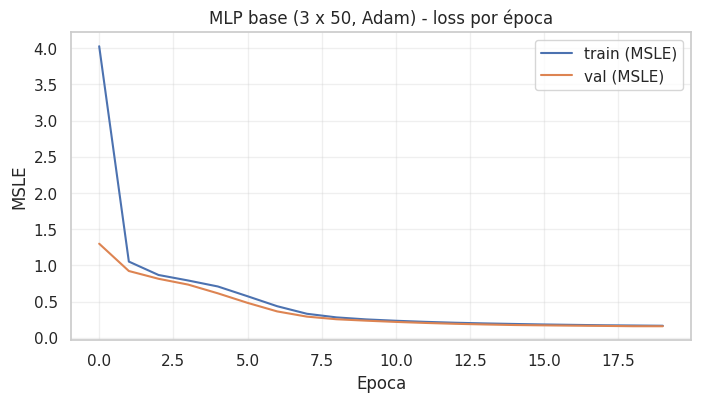

In [16]:
# Parametros entrenables: 3 capas ocultas de 50 + capa de salida de 1
input_dim  = X_train.shape[1]
hidden     = 50

manual_params = (
    (input_dim + 1) * hidden     # input -> hidden1
    + (hidden + 1)    * hidden   # hidden1 -> hidden2
    + (hidden + 1)    * hidden   # hidden2 -> hidden3
    + (hidden + 1)    * 1        # hidden3 -> output
)

mlp_model.summary()
print(f"Parametros entrenables (manual): {manual_params}")
print(f"Parametros entrenables (Keras):  {mlp_model.count_params()}")

history_df = pd.DataFrame(history_base.history)
display(history_df.head())

plt.figure(figsize=(8, 4))
plt.plot(history_df.index, history_df["loss"],     label="train (MSLE)")
plt.plot(history_df.index, history_df["val_loss"], label="val (MSLE)")
plt.xlabel("Epoca")
plt.ylabel("MSLE")
plt.title("MLP base (3 x 50, Adam) - loss por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Parte 3 - Ajuste fino (Keras Tuner)

Siguiendo el ejemplo de la sección *Fine-Tuning Neural Network Hyperparameters*:


*   Utilizar la herramienta *RandomSearch* de *KerasTuner* para la busqueda de hiperparámetros del modelo implementado en *keras*.
*   Probar el *tip* que se sugiere en la sección *Number of Neurons per Hidden Layer* y comentar los resultados.

*Nota: Keras Tuner permite realizar Optimización bayesiana.*

In [17]:
from pathlib import Path
from tensorflow import keras

class RandomSearchNoTensorBoard(kt.RandomSearch):
    """Evita la dependencia opcional con tensorboard durante la búsqueda."""

    def _configure_tensorboard_dir(self, callbacks, trial, execution=0):
        return

def build_tunable_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=128, step=16)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-1, sampling="log")
    first_layer_wider = hp.Boolean("first_layer_wider")

    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    for layer_idx in range(n_hidden):
        units = n_neurons * 2 if first_layer_wider and layer_idx == 0 else n_neurons
        model.add(keras.layers.Dense(units, activation="relu"))

    model.add(keras.layers.Dense(1))

    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer)
    return model

tuner_dir = Path("models") / "keras_tuner"
random_search = RandomSearchNoTensorBoard(
    hypermodel=build_tunable_model,
    objective="val_loss",
    max_trials=10,
    overwrite=True,
    directory=str(tuner_dir),
    project_name="bike_demand_random_search",
    seed=42,
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

random_search.search_space_summary()

Search space summary
Default search space size: 4
n_hidden (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
n_neurons (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
first_layer_wider (Boolean)
{'default': False, 'conditions': []}


In [18]:
random_search.search(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping_cb],
    verbose=1,
)


Trial 10 Complete [00h 00m 39s]
val_loss: 1.1508965492248535

Best val_loss So Far: 0.2692785859107971
Total elapsed time: 00h 06m 10s


In [19]:
best_hp = random_search.get_best_hyperparameters(num_trials=1)[0]

# Semilla fijada ANTES de construir el modelo para que la inicialización
# de los pesos sea reproducible entre corridas del notebook.
keras.utils.set_random_seed(42)
best_model = random_search.hypermodel.build(best_hp)

best_history = best_model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping_cb],
    verbose=1,
)

best_val_loss = min(best_history.history["val_loss"])

print("Mejores hiperparametros encontrados:")
for name, value in best_hp.values.items():
    print(f"- {name}: {value}")

print(f"Mejor val_loss reentrenando el mejor modelo: {best_val_loss:.4f}")
random_search.results_summary()


Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4332 - val_loss: 0.9364
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8819 - val_loss: 0.8050
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8023 - val_loss: 0.7510
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7705 - val_loss: 0.7284
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7507 - val_loss: 0.7170
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7338 - val_loss: 0.6958
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7155 - val_loss: 0.6731
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6928 - val_loss: 0.6483
Epoch 9/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6598 - val_loss: 0.6111
Epoch 10/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6070 - val_loss: 0.5610
Epoch 11/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5259 - val_loss: 0.4929
Epoch 12/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [20]:
def build_fixed_model(n_hidden, n_neurons, learning_rate, first_layer_wider=False):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    for layer_idx in range(n_hidden):
        units = n_neurons * 2 if first_layer_wider and layer_idx == 0 else n_neurons
        model.add(keras.layers.Dense(units, activation="relu"))

    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer)
    return model

comparison_rows = []

for architecture_name, first_layer_wider in [
    ("mismo_numero_por_capa", False),
    ("primera_capa_mas_grande", True),
]:
    keras.utils.set_random_seed(42)
    model = build_fixed_model(
        n_hidden=best_hp.get("n_hidden"),
        n_neurons=best_hp.get("n_neurons"),
        learning_rate=best_hp.get("learning_rate"),
        first_layer_wider=first_layer_wider,
    )

    arch_history = model.fit(
        X_train,
        y_train,
        epochs=30,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping_cb],
        verbose=0,
    )

    comparison_rows.append({
        "arquitectura": architecture_name,
        "best_val_loss": min(arch_history.history["val_loss"]),
        "epochs_entrenadas": len(arch_history.history["val_loss"]),
        "parametros": model.count_params(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("best_val_loss")
display(comparison_df)

best_architecture = comparison_df.iloc[0]["arquitectura"]
best_architecture_loss = comparison_df.iloc[0]["best_val_loss"]
print(f"La mejor variante para este dataset fue: {best_architecture} (val_loss={best_architecture_loss:.4f})")


,arquitectura,best_val_loss,epochs_entrenadas,parametros
1,primera_capa_mas_grande,0.717042,5,3905
0,mismo_numero_por_capa,0.726608,5,1985


La mejor variante para este dataset fue: primera_capa_mas_grande (val_loss=0.7170)


## Parte 4 - Ajuste fino (Optuna)

*   Utilizar *Optuna* para la busqueda de hiperparámetros del modelo en *Keras*. Se le sugiere seguir uno de los siguientes ejemplos: [*keras_simple*](https://github.com/optuna/optuna-examples/blob/main/keras/keras_simple.py),  [OptunaSearchCV](https://github.com/optuna/optuna-examples/blob/main/sklearn/sklearn_optuna_search_cv_simple.py).

*Nota 1: Optuna puede utilizarse para optimizar otras técnicas por fuera de las redes neuronales, y otros frameworks además de Keras.*


In [21]:
%pip install optuna

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


En este notebook se usa el enfoque directo de **Optuna** con una función `objective(trial)`, en lugar de `OptunaSearchCV`. Esto deja más claro qué hiperparámetros se están optimizando y evita depender de `scikeras`.

*Nota:* si más adelante quisiera probar `OptunaSearchCV`, las instalaciones compatibles quedan comentadas como referencia, pero no son necesarias para resolver esta parte.

In [22]:
# Instalaciones opcionales solo si se quisiera probar OptunaSearchCV
# %pip install scikeras==0.13.0
# %pip install scikit-learn==1.4.2
# %pip install optuna-integration[sklearn]

import optuna
from tensorflow import keras

def build_optuna_model(n_hidden, n_neurons, learning_rate, first_layer_wider=False):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    for layer_idx in range(n_hidden):
        units = n_neurons * 2 if first_layer_wider and layer_idx == 0 else n_neurons
        model.add(keras.layers.Dense(units, activation="relu"))

    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer)
    return model

def objective(trial):
    n_hidden = trial.suggest_int("n_hidden", 1, 3)
    n_neurons = trial.suggest_int("n_neurons", 16, 128, step=16)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    first_layer_wider = trial.suggest_categorical("first_layer_wider", [False, True])

    keras.utils.set_random_seed(42)
    model = build_optuna_model(
        n_hidden=n_hidden,
        n_neurons=n_neurons,
        learning_rate=learning_rate,
        first_layer_wider=first_layer_wider,
    )

    early_stopping_cb = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping_cb],
        verbose=0,
    )

    best_val_loss = min(history.history["val_loss"])
    trial.set_user_attr("epochs_trained", len(history.history["val_loss"]))
    return best_val_loss


/home/santig14/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[I 2026-04-23 00:18:14,404] A new study created in memory with name: bike_demand_optuna
[I 2026-04-23 00:19:21,269] Trial 0 finished with value: 0.5438507795333862 and parameters: {'n_hidden': 2, 'n_neurons': 128, 'learning_rate': 0.015702970884055395, 'batch_size': 16, 'first_layer_wider': True}. Best is trial 0 with value: 0.5438507795333862.
[I 2026-04-23 00:20:25,076] Trial 1 finished with value: 2.0042977333068848 and parameters: {'n_hidden': 2, 'n_neurons': 96, 'learning_rate': 0.00011527987128232407, 'batch_size': 16, 'first_layer_wider': True}. Best is trial 0 with value: 0.5438507795333862.
[I 2026-04-23 00:20:57,375] Trial 2 finished with value: 1.4840927124023438 and parameters: {'n_hidden': 1, 'n_neurons': 80, 'learning_rate': 0.0019762189340280074, 'batch_size': 32, 'first_layer_wider': True}. Best is trial 0 with value: 0.5438507795333862.
[I 2026-04-23 00:21:33,363] Trial 3 finished with value: 1.6588383913040161 and parameters: {'n_hidden': 2, 'n_neurons': 112, 'learnin

Mejor trial: 14
Mejor val_loss encontrado por Optuna: 0.1690
Mejores hiperparametros encontrados:
- n_hidden: 3
- n_neurons: 48
- learning_rate: 0.04290121933981894
- batch_size: 32
- first_layer_wider: True
Epochs entrenadas en el mejor trial: 30
Primera capa mas grande segun Optuna: True
Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.4596 - val_loss: 0.9447
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8831 - val_loss: 0.8175
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8070 - val_loss: 0.7584
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7648 - val_loss: 0.7221
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7340 - val_loss: 0.6911
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7025 - val_loss: 0.6572
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6642 - val_loss: 0.6119
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6109 - val_loss: 0.5487
Epoch 9/30
307/307 ━━

,number,value,params_batch_size,params_first_layer_wider,params_learning_rate,params_n_hidden,params_n_neurons,state,user_attrs_epochs_trained
14,14,0.169037,32,True,0.042901,3,48,COMPLETE,30
6,6,0.218384,32,True,0.081050,2,32,COMPLETE,30
15,15,0.356491,32,True,0.042189,2,48,COMPLETE,30
10,10,0.382484,64,True,0.081024,3,16,COMPLETE,22
11,11,0.405586,64,True,0.091160,3,16,COMPLETE,20


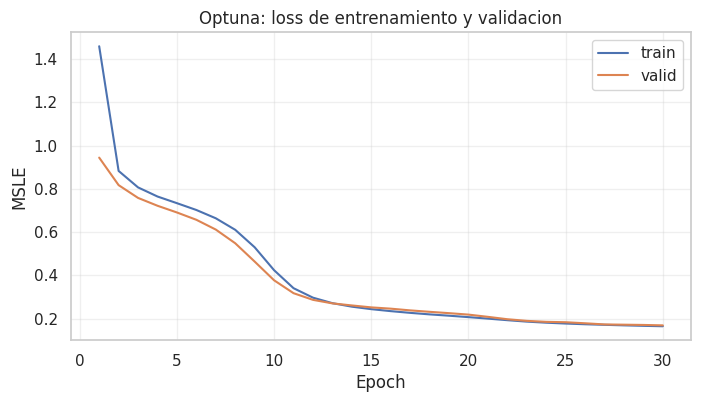

In [23]:
optuna_sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    direction="minimize",
    sampler=optuna_sampler,
    study_name="bike_demand_optuna",
)

study.optimize(objective, n_trials=20, show_progress_bar=False)

best_trial = study.best_trial
best_params = best_trial.params

print(f"Mejor trial: {best_trial.number}")
print(f"Mejor val_loss encontrado por Optuna: {best_trial.value:.4f}")
print("Mejores hiperparametros encontrados:")
for name, value in best_params.items():
    print(f"- {name}: {value}")
print(f"Epochs entrenadas en el mejor trial: {best_trial.user_attrs['epochs_trained']}")
print(f"Primera capa mas grande segun Optuna: {best_params['first_layer_wider']}")

keras.utils.set_random_seed(42)
optuna_best_model = build_optuna_model(
    n_hidden=best_params["n_hidden"],
    n_neurons=best_params["n_neurons"],
    learning_rate=best_params["learning_rate"],
    first_layer_wider=best_params["first_layer_wider"],
)

optuna_early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

optuna_best_history = optuna_best_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=best_params["batch_size"],
    validation_data=(X_valid, y_valid),
    callbacks=[optuna_early_stopping_cb],
    verbose=1,
)

optuna_trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state", "user_attrs"))
display(optuna_trials_df.sort_values("value").head())

optuna_history_df = pd.DataFrame(optuna_best_history.history)
plt.figure(figsize=(8, 4))
plt.plot(optuna_history_df.index + 1, optuna_history_df["loss"], label="train")
plt.plot(optuna_history_df.index + 1, optuna_history_df["val_loss"], label="valid")
plt.xlabel("Epoch")
plt.ylabel("MSLE")
plt.title("Optuna: loss de entrenamiento y validacion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Comparativa de resultados

Antes de construir el pipeline final, se comparan los mejores resultados obtenidos en la Parte 2 (modelo base), Parte 3 (Keras Tuner) y Parte 4 (Optuna).

,enfoque,best_val_loss,epochs_entrenadas,parametros,n_hidden,n_neurons,learning_rate,batch_size,first_layer_wider
0,Parte 2 - MLP base,0.160670,20,6551,3,50,NaN,NaN,False
1,Parte 4 - Optuna,0.169037,30,9745,3,48,0.042901,32.0,True
2,Parte 3 - Keras Tuner,0.206717,30,3905,2,32,0.086112,32.0,True


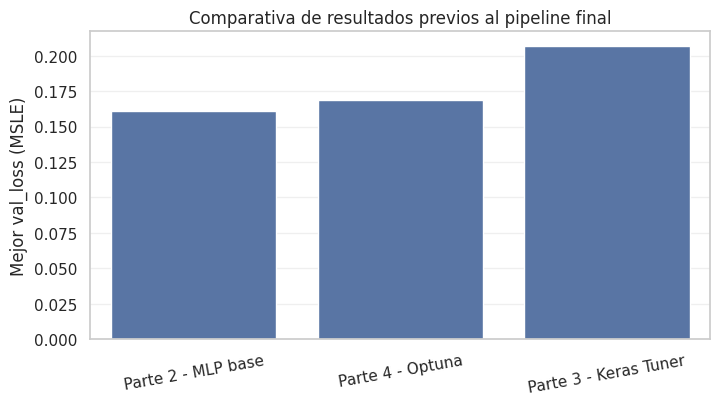

Mejor enfoque hasta ahora: Parte 2 - MLP base con val_loss=0.1607


In [24]:
required_objects = [
    "history_base",
    "mlp_model",
    "best_hp",
    "best_history",
    "best_val_loss",
    "best_model",
    "best_trial",
    "optuna_best_history",
    "optuna_best_model",
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Ejecute primero completas las Partes 2, 3 y 4 antes de comparar resultados. "
        f"Faltan: {missing_objects}"
    )

part2_best_val_loss = min(history_base.history["val_loss"])
part3_best_val_loss = best_val_loss
part4_best_val_loss = min(optuna_best_history.history["val_loss"])

comparison_results = pd.DataFrame([
    {
        "enfoque": "Parte 2 - MLP base",
        "best_val_loss": part2_best_val_loss,
        "epochs_entrenadas": len(history_base.history["val_loss"]),
        "parametros": mlp_model.count_params(),
        "n_hidden": 3,
        "n_neurons": 50,
        "learning_rate": None,           # Adam default (1e-3)
        "batch_size": None,              # default de Keras (32)
        "first_layer_wider": False,
    },
    {
        "enfoque": "Parte 3 - Keras Tuner",
        "best_val_loss": part3_best_val_loss,
        "epochs_entrenadas": len(best_history.history["val_loss"]),
        "parametros": best_model.count_params(),
        "n_hidden": best_hp.get("n_hidden"),
        "n_neurons": best_hp.get("n_neurons"),
        "learning_rate": best_hp.get("learning_rate"),
        "batch_size": 32,
        "first_layer_wider": best_hp.get("first_layer_wider"),
    },
    {
        "enfoque": "Parte 4 - Optuna",
        "best_val_loss": part4_best_val_loss,
        "epochs_entrenadas": len(optuna_best_history.history["val_loss"]),
        "parametros": optuna_best_model.count_params(),
        "n_hidden": best_trial.params["n_hidden"],
        "n_neurons": best_trial.params["n_neurons"],
        "learning_rate": best_trial.params["learning_rate"],
        "batch_size": best_trial.params["batch_size"],
        "first_layer_wider": best_trial.params["first_layer_wider"],
    },
]).sort_values("best_val_loss").reset_index(drop=True)

display(comparison_results)

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_results, x="enfoque", y="best_val_loss")
plt.ylabel("Mejor val_loss (MSLE)")
plt.xlabel("")
plt.title("Comparativa de resultados previos al pipeline final")
plt.xticks(rotation=10)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

best_result_row = comparison_results.iloc[0]
print(
    f"Mejor enfoque hasta ahora: {best_result_row['enfoque']} "
    f"con val_loss={best_result_row['best_val_loss']:.4f}"
)


## Parte 5 - Pipeline



*   Incorporar el estimador con mejor desempeño a un *pipeline* similar al implementado en el Taller 3. Puede ser útil la biblioteca [scikeras](https://adriangb.com/scikeras/stable/migration.html).
*   Subir los resultados de los datos *test* a la página de la competencia.



In [25]:
from pathlib import Path

from scikeras.wrappers import KerasRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from tensorflow import keras

required_objects = ["comparison_results"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Ejecute primero la celda de comparativa antes de construir el pipeline final. "
        f"Faltan: {missing_objects}"
    )

pipeline_train_df = pd.read_csv("data/data_taller3/train.csv")
pipeline_test_df = pd.read_csv("data/data_taller3/test.csv")
pipeline_submission_df = pd.read_csv("data/data_taller3/sampleSubmission.csv")
y_pipeline_train = pipeline_train_df["count"].copy()

def prepare_bike_pipeline_features(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["hour"] = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.weekday
    df["month"] = df["datetime"].dt.month
    df["year"] = df["datetime"].dt.year

    drop_cols = ["datetime"]
    for col in ["casual", "registered", "count"]:
        if col in df.columns:
            drop_cols.append(col)

    return df.drop(columns=drop_cols)

categorical_cols = ["workingday", "weekday", "weather", "season", "holiday", "year"]
numeric_cols = ["temp", "atemp", "humidity", "windspeed", "hour", "month"]

best_result_row = comparison_results.iloc[0]

if best_result_row["enfoque"] == "Parte 2 - MLP base":
    selected_config = {
        "source": best_result_row["enfoque"],
        "n_hidden": 3,
        "n_neurons": 50,
        "learning_rate": None,
        "optimizer": "adam",
        "batch_size": 32,
        "first_layer_wider": False,
        "epochs": 20,
    }
elif best_result_row["enfoque"] == "Parte 3 - Keras Tuner":
    selected_config = {
        "source": best_result_row["enfoque"],
        "n_hidden": int(best_hp.get("n_hidden")),
        "n_neurons": int(best_hp.get("n_neurons")),
        "learning_rate": float(best_hp.get("learning_rate")),
        "optimizer": "sgd",
        "batch_size": 32,
        "first_layer_wider": bool(best_hp.get("first_layer_wider")),
        "epochs": 30,
    }
else:
    selected_config = {
        "source": best_result_row["enfoque"],
        "n_hidden": int(best_trial.params["n_hidden"]),
        "n_neurons": int(best_trial.params["n_neurons"]),
        "learning_rate": float(best_trial.params["learning_rate"]),
        "optimizer": "sgd",
        "batch_size": int(best_trial.params["batch_size"]),
        "first_layer_wider": bool(best_trial.params["first_layer_wider"]),
        "epochs": 30,
    }

def build_pipeline_model(meta, n_hidden, n_neurons, learning_rate, optimizer_name, first_layer_wider):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(meta["n_features_in_"],)))

    for layer_idx in range(n_hidden):
        units = n_neurons * 2 if first_layer_wider and layer_idx == 0 else n_neurons
        model.add(keras.layers.Dense(units, activation="relu"))

    model.add(keras.layers.Dense(1))

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam() if learning_rate is None else keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizer_name}")

    model.compile(loss="mean_squared_logarithmic_error", optimizer=optimizer)
    return model

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

final_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(prepare_bike_pipeline_features, validate=False)),
    ("preprocessor", final_preprocessor),
    (
        "model",
        KerasRegressor(
            model=build_pipeline_model,
            model__n_hidden=selected_config["n_hidden"],
            model__n_neurons=selected_config["n_neurons"],
            model__learning_rate=selected_config["learning_rate"],
            model__optimizer_name=selected_config["optimizer"],
            model__first_layer_wider=selected_config["first_layer_wider"],
            epochs=selected_config["epochs"],
            batch_size=selected_config["batch_size"],
            validation_split=0.1,
            callbacks=[early_stopping_cb],
            verbose=1,
            random_state=42,
        ),
    ),
])

print(f"Se incorporará al pipeline el mejor enfoque previo: {selected_config['source']}")
for name, value in selected_config.items():
    if name != "source":
        print(f"- {name}: {value}")


Se incorporará al pipeline el mejor enfoque previo: Parte 2 - MLP base
- n_hidden: 3
- n_neurons: 50
- learning_rate: None
- optimizer: adam
- batch_size: 32
- first_layer_wider: False
- epochs: 20


In [26]:
keras.utils.set_random_seed(42)

final_pipeline.fit(pipeline_train_df, y_pipeline_train)

train_predictions = np.clip(final_pipeline.predict(pipeline_train_df), a_min=0, a_max=None)
final_train_msle = mean_squared_log_error(y_pipeline_train, train_predictions)

test_predictions = np.clip(final_pipeline.predict(pipeline_test_df), a_min=0, a_max=None)

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

final_submission = pipeline_submission_df.copy()
final_submission["count"] = test_predictions

submission_path = results_dir / "bike_demand_submission_pipeline.csv"
final_submission.to_csv(submission_path, index=False)

print(f"MSLE sobre train completo (solo referencia): {final_train_msle:.4f}")
print(f"Archivo generado: {submission_path}")
display(final_submission.head())

print("Para enviar la submission desde consola:")
print(f"!kaggle competitions submit -c bike-sharing-demand -f {submission_path} -m demanda_con_NN_pipeline")


Epoch 1/20


E0000 00:00:1776915039.810686  141410 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.9999 - val_loss: 1.4616
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0367 - val_loss: 1.0087
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8544 - val_loss: 0.8599
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7694 - val_loss: 0.7733
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6722 - val_loss: 0.6437
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5450 - val_loss: 0.5063
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4163 - val_loss: 0.3807
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3147 - val_loss: 0.2987
Epoch 9/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2756 - val_loss: 0.2625
Epoch 10/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2563 - val_loss: 0.2433
Epoch 11/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2426 - val_loss: 0.2285
Epoch 12/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.

,datetime,count
0,2011-01-20 00:00:00,9.930773
1,2011-01-20 01:00:00,4.781065
2,2011-01-20 02:00:00,2.003345
3,2011-01-20 03:00:00,1.776244
4,2011-01-20 04:00:00,1.198417


Para enviar la submission desde consola:
!kaggle competitions submit -c bike-sharing-demand -f results/bike_demand_submission_pipeline.csv -m demanda_con_NN_pipeline


In [27]:
!kaggle competitions submit -c bike-sharing-demand -f results/bike_demand_submission_pipeline.csv -m demanda_con_NN_pipeline

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
100%|█████████████████████████████████████████| 188k/188k [00:01<00:00, 119kB/s]
Successfully submitted to Bike Sharing Demand